# Семинар 7. RAG: чанкинг, гибридный поиск и реранкинг

На лекциях модуля мы разобрали Retrieval-Augmented Generation: как внешние документы подключаются к модели во время генерации и почему качество RAG-системы во многом определяется тем, насколько хорошо работает поиск. Сегодня соберем поисковую часть RAG своими руками и разберем ключевые компоненты, которые превращают поиск из простого сопоставления текстов в действительно рабочий механизм.

## Что мы сделаем

1. Соберем коллекцию документов из открытого датасета и разделим ее на фрагменты (чанки).
2. Построим векторный индекс с нуля и реализуем функцию поиска.
3. Оценим качество поиска до подключения генерации с помощью метрик Recall@k и MRR.
4. Сравним три подхода к поиску: лексический (BM25), семантический и гибридный.
5. Добавим реранкинг с помощью кросс-энкодера и измерим, насколько он улучшает качество поиска.
6. В конце подключим генерацию и на простом примере увидим связь между качеством поиска и качеством итогового ответа: "качество поиска -> качество ответа".

## Связь с ДЗ

В ДЗ вы получите уже готовый корпус, разделенный на фрагменты, и сосредоточитесь на генеративной части RAG: grounding, цитировании источников, LLM-as-a-judge и устойчивости к галлюцинациям. Здесь мы, наоборот, подробно разберем поисковую часть: самостоятельно соберем индекс, посмотрим, как чанкинг влияет на результаты, сравним лексический, семантический и гибридный поиск и добавим реранкинг.

## Как устроено занятие

Мы будем последовательно проходить по ячейкам, запускать эксперименты и сравнивать результаты. По ходу занятия будем останавливаться на вопросах и разбирать, почему тот или иной подход работает или дает сбой.

Главный принцип семинара - сначала научиться измерять и улучшать поиск, а уже потом оценивать генерацию. Это позволит рассматривать RAG не как одну большую "черную коробку", а как последовательность отдельных компонентов, качество которых можно диагностировать и улучшать независимо.



## Блок 0. Подготовка окружения

Нам понадобятся:
- `sentence-transformers` - для построения эмбеддингов и работы с кросс-энкодером;
- `faiss` - для построения векторного индекса и быстрого поиска;
- `rank_bm25` - для лексического поиска с помощью BM25;
- `transformers` - для запуска небольшой генеративной модели в финальной части занятия.

Занятие рекомендуется запускать на GPU. В Google Colab его можно включить через Runtime -> Change runtime type -> GPU. Это заметно ускорит вычисление эмбеддингов, работу реранкера и генерацию ответов.



In [1]:
!pip install -q -U sentence-transformers faiss-cpu rank_bm25 datasets transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 12.9 MB/s eta 0:00:00


In [2]:
import re
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi
import faiss

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

EMB_MODEL = "intfloat/multilingual-e5-small" # модель эмбеддингов (bi-encoder)
RERANKER_MODEL = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1" # мультиязычный кросс-энкодер
LLM_MODEL = "Qwen/Qwen2.5-1.5B-Instruct" # маленькая instruct-модель

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## Блок 1. Данные и коллекция документов

Возьмем открытый датасет SberQuAD - набор вопросов к абзацам русскоязычной Википедии. Каждый пример содержит вопрос, контекст, в котором находится ответ, и сам ответ.

Для нашей задачи этот датасет удобен сразу по двум причинам:

- контексты станут коллекцией документов, по которой мы будем выполнять поиск;
- для каждого вопроса заранее известен "правильный" контекст, поэтому мы сможем объективно оценить качество поиска без дополнительной ручной разметки.

In [3]:
ds = load_dataset("kuznetsoffandrey/sberquad")
raw = ds["train"]
print(raw)
print("\nПример записи:")
print("вопрос: ", raw[0]["question"])
print("контекст:", raw[0]["context"][:200], "...")
print("ответ: ", raw[0]["answers"]["text"])

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

sberquad/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.4MB            

sberquad/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sberquad/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 3.43MB            

sberquad/validation-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

...

sberquad/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 45328
})

Пример записи:
вопрос:  чем представлены органические остатки?
контекст: В протерозойских отложениях органические остатки встречаются намного чаще, чем в архейских. Они представлены известковыми выделениями сине-зелёных водорослей, ходами червей, остатками кишечнополостных ...
ответ:  ['известковыми выделениями сине-зелёных водорослей']


In [4]:
# Собираем коллекцию уникальных документов из контекстов
context_to_id = {}
documents = [] # список словарей {doc_id, text}

for ex in raw:
    ctx = ex["context"].strip()
    if ctx not in context_to_id:
        context_to_id[ctx] = len(documents)
        documents.append({"doc_id": len(documents), "text": ctx})

# Для каждого вопроса запоминаем gold документ (тот, откуда взят ответ)
questions = []
for ex in raw:
    ctx = ex["context"].strip()
    ans = ex["answers"]["text"][0] if ex["answers"]["text"] else ""
    questions.append({"question": ex["question"].strip(), "gold_doc": context_to_id[ctx], "answer": ans})

print("Уникальных документов:", len(documents))
print("Вопросов всего:", len(questions))

Уникальных документов: 9078
Вопросов всего: 45328


In [5]:
# Возьмем подвыборку документов и относящиеся к ним вопросы
N_DOCS = 3000
keep = set(range(min(N_DOCS, len(documents))))

documents = [d for d in documents if d["doc_id"] in keep]
questions = [q for q in questions if q["gold_doc"] in keep]

random.shuffle(questions)
questions = questions[:300] # проверочный набор

print("Документов:", len(documents))
print("Проверочных вопросов:", len(questions))

Документов: 3000
Проверочных вопросов: 300


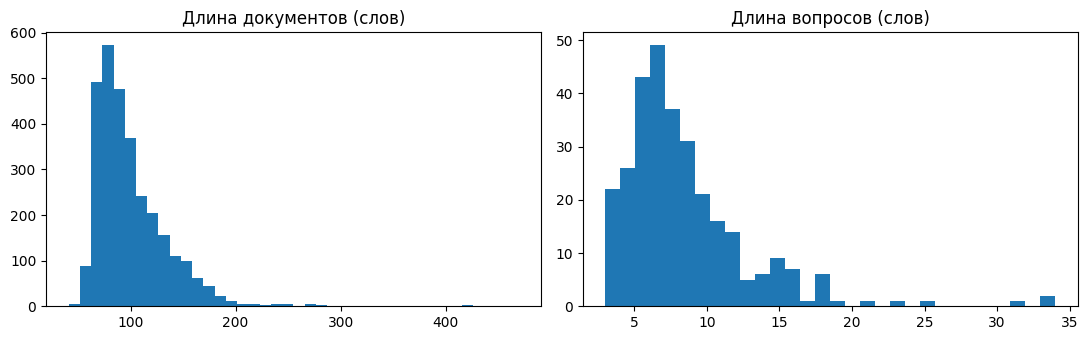

Медианная длина документа: 91 слов
Медианная длина вопроса: 8 слов


In [6]:
# Небольшой обзор данных
doc_lens = [len(d["text"].split()) for d in documents]
q_lens = [len(q["question"].split()) for q in questions]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(doc_lens, bins=40)
ax[0].set_title("Длина документов (слов)")
ax[1].hist(q_lens, bins=30)
ax[1].set_title("Длина вопросов (слов)")
plt.tight_layout()
plt.show()

print("Медианная длина документа:", int(np.median(doc_lens)), "слов")
print("Медианная длина вопроса:", int(np.median(q_lens)), "слов")

**Вопрос**

Наши документы - это абзацы, на основе которых были составлены вопросы. Как это может сделать оценку качества поиска слишком оптимистичной по сравнению с реальной задачей, где пользователь формулирует вопрос независимо от текста документа?


## Блок 2. Чанкинг

Документы редко подаются в поиск целиком. Вместо этого длинный текст разбивают на небольшие фрагменты - чанки. Это помогает точнее находить нужную информацию и не перегружать контекст модели лишним текстом.

При выборе размера чанка важно найти баланс:

* слишком маленькие чанки могут разрывать смысл: например, вопрос и ответ окажутся в разных фрагментах;
* слишком крупные чанки содержат много лишнего текста, из-за чего поиск становится менее точным.

Разберем два способа нарезки и сравним получившиеся чанки визуально.


In [7]:
def fixed_word_chunks(text, size=60, overlap=15):
    """Нарезка по фиксированному числу слов с перекрытием."""
    words = text.split()
    if len(words) <= size:
        return [text]
    chunks, step = [], size - overlap
    for start in range(0, len(words), step):
        piece = words[start:start + size]
        if piece:
            chunks.append(" ".join(piece))
        if start + size >= len(words):
            break
    return chunks

def sentence_chunks(text, max_words=60):
    """Нарезка по предложениям: копим предложения, пока не превысим лимит слов."""
    sents = re.split(r"(?<=[.!?])\s+", text)
    chunks, cur, cur_len = [], [], 0
    for s in sents:
        w = len(s.split())
        if cur and cur_len + w > max_words:
            chunks.append(" ".join(cur))
            cur, cur_len = [], 0
        cur.append(s)
        cur_len += w
    if cur:
        chunks.append(" ".join(cur))
    return chunks

In [8]:
# Посмотрим на нарезку самого длинного документа
long_doc = max(documents, key=lambda d: len(d["text"].split()))
print("Документ из", len(long_doc["text"].split()), "слов\n")

print("Мелкая нарезка (size=20):")
for c in fixed_word_chunks(long_doc["text"], size=20, overlap=5)[:3]:
    print("  -", c[:110], "...")

print("\nНарезка по предложениям (max_words=60):")
for c in sentence_chunks(long_doc["text"], max_words=60)[:3]:
    print("  -", c[:110], "...")

Документ из 469 слов

Мелкая нарезка (size=20):
  - За участие в кампании 1809 г. против Австрии Бавария получила в награду княжество Регенсбург, маркграфства Бай ...
  - Байройт, Зальцбург, Берхтесгаден, уступив, со своей стороны, Южный Тироль, Ульм и некоторые другие округи. Бав ...
  - насчитывала в это время 3 млн. 300 тыс. жителей. В Русской кампании 1812 г., баварский контингент в 30000 чел. ...

Нарезка по предложениям (max_words=60):
  - За участие в кампании 1809 г. против Австрии Бавария получила в награду княжество Регенсбург, маркграфства Бай ...
  - она выставила новую армию под команду Наполеона и вместе с тем сосредоточила наблюдательный корпус на австрийс ...
  - за ней обеспечены были все остальные владения, вместе с Вюрцбургом, Ашаффенбургом и некоторой частью левого бе ...


In [9]:
def build_chunks(documents, strategy="sentence", **kwargs):
    """Разбивает документы на чанки и сохраняет связь каждого чанка с исходным документом."""
    records = []
    for d in documents:
        pieces = fixed_word_chunks(d["text"], **kwargs) if strategy == "fixed" else sentence_chunks(d["text"], **kwargs)
        for p in pieces:
            records.append({"chunk_id": len(records), "doc_id": d["doc_id"], "text": p})
    return records

# две конфигурации
chunks_small = build_chunks(documents, strategy="fixed", size=20, overlap=5)
chunks_ok = build_chunks(documents, strategy="sentence", max_words=60)

print("Мелких чанков (20 слов):", len(chunks_small))
print("Чанков по предложениям (~60):", len(chunks_ok))

Мелких чанков (20 слов): 20513
Чанков по предложениям (~60): 7163


**Вопрос**

Мелкая нарезка дает больше фрагментов и позволяет точнее локализовать место ответа. Почему при этом Recall@k может упасть?


## Блок 3. Векторный индекс своими руками

Теперь превратим наши фрагменты в векторы и построим индекс для поиска по косинусной близости.

Используем модель эмбеддингов семейства E5. Она обучалась с учетом специальных префиксов: запросы подаются в формате "query: ...", а документы - "passage: ...". Если перепутать префиксы или вовсе их не добавить, качество поиска может заметно снизиться.

Чтобы не допустить такой ошибки, вынесем подготовку текстов и построение эмбеддингов в отдельную функцию. В ДЗ вы встретите такую же обертку.


In [10]:
emb_model = SentenceTransformer(EMB_MODEL, device=device)

def embed(texts, kind):
    assert kind in ("query", "passage")
    prefixed = [f"{kind}: {t}" for t in texts]
    return emb_model.encode(prefixed, normalize_embeddings=True, convert_to_numpy=True, batch_size=64, show_progress_bar=False)

def build_index(chunks):
    vecs = embed([c["text"] for c in chunks], kind="passage").astype("float32")
    index = faiss.IndexFlatIP(vecs.shape[1]) # inner product на нормированных векторах = косинус
    index.add(vecs)
    return index

def make_dense_retriever(chunks, index):
    def retrieve(query, k=5):
        qv = embed([query], kind="query").astype("float32")
        scores, ids = index.search(qv, k)
        return [(chunks[i], float(s)) for s, i in zip(scores[0], ids[0])]
    return retrieve

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [11]:
# Строим индекс на чанкинге по предложениям и смотрим на поиск глазами
index_ok = build_index(chunks_ok)
dense_retrieve = make_dense_retriever(chunks_ok, index_ok)

demo_q = questions[0]["question"]
print("Запрос:", demo_q, "\n")
for ch, sc in dense_retrieve(demo_q, k=3):
    print(f"[{sc:.3f}] doc={ch['doc_id']:>4} | {ch['text'][:120]}...")

Запрос: Чем стала морская свинка для жителей Анд, став одомашненной? 

[0.857] doc=2548 | Позже возникли новые очаги одомашнивания. В Андах в конце III — начале II тысячелетия до н. э. одомашнили гуанако (к кот...
[0.804] doc=2548 | в Египте появилась одомашненная форма лесного хорька — фретка, а в I тысячелетии н. э. во Франции был одомашнен кролик. ...
[0.804] doc=1904 | Мера агрессии, мера меланхолии, своеобразная блюз-роковая платформа, какое-то количество кантри, которое Андрей достаточ...


**Вопрос**

Мы используем `faiss.IndexFlatIP` (inner product) на L2-нормированных векторах. Почему это дает именно косинусную близость?



## Блок 4. Оцениваем поиск

Прежде чем подключать генерацию, оценим качество самого поиска. Это один из ключевых принципов диагностики RAG-систем: если релевантный фрагмент не найден, генеративной модели просто не из чего строить ответ.

Используем две метрики:

- **Recall@k** - доля вопросов, для которых релевантный документ попал в top-k результатов;
- **MRR (Mean Reciprocal Rank)** - среднее значение величины `1 / rank`, где `rank` - позиция первого релевантного документа в выдаче. Чем выше релевантный документ в результатах, тем больше вклад этого запроса в итоговую метрику.

In [12]:
def evaluate_retrieval(retrieve_fn, questions, ks=(1, 3, 5, 10), mrr_at=10):
    max_k = max(max(ks), mrr_at)
    recall_hits = {k: 0 for k in ks}
    rr_sum = 0.0
    for q in questions:
        found = [ch["doc_id"] for ch, _ in retrieve_fn(q["question"], k=max_k)]
        for k in ks:
            if q["gold_doc"] in found[:k]:
                recall_hits[k] += 1
        rank = next((i + 1 for i, d in enumerate(found[:mrr_at]) if d == q["gold_doc"]), None)
        if rank:
            rr_sum += 1.0 / rank
    n = len(questions)
    out = {f"Recall@{k}": recall_hits[k] / n for k in ks}
    out[f"MRR@{mrr_at}"] = rr_sum / n
    return out

res_ok = evaluate_retrieval(dense_retrieve, questions)
pd.DataFrame([res_ok], index=["dense, чанкинг по предложениям"]).round(3)

,Recall@1,Recall@3,Recall@5,Recall@10,MRR@10
"dense, чанкинг по предложениям",0.907,0.96,0.98,0.98,0.936


In [13]:
# Проверим влияние чанкинга: тот же поиск, но на мелком чанкинге
index_small = build_index(chunks_small)
dense_retrieve_small = make_dense_retriever(chunks_small, index_small)
res_small = evaluate_retrieval(dense_retrieve_small, questions)

pd.DataFrame(
    [res_small, res_ok],
    index=["dense, мелкая нарезка (20 слов)", "dense, по предложениям (~60 слов)"]
).round(3)

,Recall@1,Recall@3,Recall@5,Recall@10,MRR@10
"dense, мелкая нарезка (20 слов)",0.903,0.957,0.973,0.983,0.931
"dense, по предложениям (~60 слов)",0.907,0.960,0.980,0.980,0.936


**Вопрос**

Если Recall@5 низкий, есть ли смысл улучшать промпт генеративной модели?


## Блок 5. Лексический, семантический и гибридный поиск

Семантический поиск хорошо улавливает смысл и устойчив к перефразировкам, но может терять точные совпадения - например, редкие термины, имена, числа или аббревиатуры. Лексический поиск BM25, наоборот, опирается на совпадение слов и поэтому особенно хорошо справляется с такими случаями.

На практике эти подходы часто объединяют в гибридный поиск. Один из простых и устойчивых способов сделать это - **Reciprocal Rank Fusion (RRF)**. Для каждого документа учитывается его позиция в каждом из поисковых списков: чем выше документ находится в выдаче, тем больший вклад он получает. Затем вклады из разных списков суммируются, формируя итоговый рейтинг.


In [14]:
def simple_tokenize(text):
    return re.findall(r"\w+", text.lower())

# BM25 строим над теми же чанками, что и плотный индекс
bm25_corpus = [simple_tokenize(c["text"]) for c in chunks_ok]
bm25 = BM25Okapi(bm25_corpus)

def bm25_retrieve(query, k=5):
    scores = bm25.get_scores(simple_tokenize(query))
    top = np.argsort(scores)[::-1][:k]
    return [(chunks_ok[i], float(scores[i])) for i in top]

def rrf_fuse(query, k=5, pool=30, k_rrf=60):
    dense_ids = [ch["chunk_id"] for ch, _ in dense_retrieve(query, k=pool)]
    bm25_ids = [ch["chunk_id"] for ch, _ in bm25_retrieve(query, k=pool)]
    scores = defaultdict(float)
    for rank, cid in enumerate(dense_ids):
        scores[cid] += 1.0 / (k_rrf + rank + 1)
    for rank, cid in enumerate(bm25_ids):
        scores[cid] += 1.0 / (k_rrf + rank + 1)
    top = sorted(scores, key=scores.get, reverse=True)[:k]
    return [(chunks_ok[cid], scores[cid]) for cid in top]

In [15]:
res_bm25 = evaluate_retrieval(bm25_retrieve, questions)
res_hybrid = evaluate_retrieval(rrf_fuse, questions)

pd.DataFrame(
    [res_bm25, res_ok, res_hybrid],
    index=["BM25", "dense", "гибрид (RRF)"]
).round(3)

,Recall@1,Recall@3,Recall@5,Recall@10,MRR@10
BM25,0.823,0.897,0.91,0.930,0.864
dense,0.907,0.960,0.98,0.980,0.936
гибрид (RRF),0.897,0.963,0.97,0.987,0.928


**Вопрос**

Придумайте запрос, на котором чистый семантический поиск, скорее всего, промахнется, а BM25 - нет.


## Блок 6. Реранкинг кросс-энкодером

Вспомним различие между двумя подходами из лекции про BERT:

- **bi-encoder** - наша модель эмбеддингов - кодирует запрос и документ независимо друг от друга. Эмбеддинги документов можно вычислить заранее, поэтому поиск получается быстрым и масштабируется на весь корпус. Обратная сторона - модель оценивает запрос и документ раздельно, поэтому точность сопоставления ограничена;
- **cross-encoder** получает пару "запрос-документ" одновременно и выдает единую оценку их релевантности. Такой подход позволяет модели учитывать взаимодействие между запросом и документом, но требует отдельного вычисления для каждой пары, поэтому он значительно дороже.

Отсюда возникает стандартная двухэтапная схема поиска: **bi-encoder** сначала быстро отбирает top-N кандидатов из всего корпуса, а затем **cross-encoder** подробно оценивает эти кандидаты и переранжирует их, формируя итоговый top-k.

Такой подход позволяет сочетать скорость и качество: дорогая модель работает только с небольшим числом уже отобранных кандидатов.

В ДЗ реранкинга не будет - разберем этот этап здесь, чтобы увидеть, как он влияет на качество поиска.


In [16]:
reranker = CrossEncoder(RERANKER_MODEL, device=device)

def rerank_retrieve(query, k=5, pool=30):
    # 1) быстрый отбор кандидатов биэнкодером
    candidates = dense_retrieve(query, k=pool)
    # 2) точное переранжирование кросс-энкодером
    pairs = [(query, ch["text"]) for ch, _ in candidates]
    ce_scores = reranker.predict(pairs)
    order = np.argsort(ce_scores)[::-1][:k]
    return [(candidates[i][0], float(ce_scores[i])) for i in order]

res_rerank = evaluate_retrieval(rerank_retrieve, questions)

pd.DataFrame(
    [res_ok, res_hybrid, res_rerank],
    index=["dense", "гибрид (RRF)", "dense + reranker"]
).round(3)

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

,Recall@1,Recall@3,Recall@5,Recall@10,MRR@10
dense,0.907,0.960,0.98,0.980,0.936
гибрид (RRF),0.897,0.963,0.97,0.987,0.928
dense + reranker,0.940,0.980,0.99,0.990,0.960


**Вопрос**

Почему нельзя использовать кросс-энкодер для поиска сразу по всему корпусу, хотя он точнее?

## Блок 7. Генерация поверх поиска

Теперь коротко подключим генерацию, чтобы увидеть главный принцип RAG: качество ответа ограничено качеством найденного контекста.

Если поиск не нашел нужную информацию, генеративной модели не из чего построить корректный ответ. Даже сильная модель не сможет надежно восполнить отсутствующий контекст.

В ДЗ вы подробно разберете grounding, цитирование источников, оценку с помощью LLM-as-a-judge и борьбу с галлюцинациями. Здесь же ограничимся несколькими примерами, чтобы на практике увидеть связь между качеством поиска и качеством итогового ответа.


In [21]:
from transformers import AutoTokenizer, AutoModelForCausalLM

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
llm = AutoModelForCausalLM.from_pretrained(LLM_MODEL, torch_dtype=torch.float16, device_map="auto")

@torch.no_grad()
def generate(system, user, max_new_tokens=50):
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    encoded = llm_tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt")
    input_ids = encoded["input_ids"].to(llm.device)
    out = llm.generate(input_ids=input_ids, max_new_tokens=max_new_tokens, do_sample=False,
                       pad_token_id=llm_tokenizer.eos_token_id)
    return llm_tokenizer.decode(out[0, input_ids.shape[1]:], skip_special_tokens=True).strip()

SYSTEM = ("Ты отвечаешь на вопрос строго по предоставленным фрагментам. "
          "Если ответа в них нет, скажи, что информации недостаточно. Отвечай кратко.")

def rag_answer(query, retrieve_fn, k=4):
    ctx = retrieve_fn(query, k=k)
    context = "\n\n".join(f"[{i+1}] {ch['text']}" for i, (ch, _) in enumerate(ctx))
    user = f"Фрагменты:\n{context}\n\nВопрос: {query}"
    return generate(SYSTEM, user), ctx

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [22]:
q = questions[1]
ans, _ = rag_answer(q["question"], rerank_retrieve, k=4)

print("Вопрос:         ", q["question"])
print("Эталонный ответ:", q["answer"])
print("Ответ RAG:      ", ans)

Вопрос:          Что проходят лучи света через чешуйки крыльев?
Эталонный ответ: Отражаются как от их внешних, так и от внутренних поверхностей
Ответ RAG:       Лучи света проходят через чешуйки крыльев, отражаются от их внешних и внутренних поверхностей, и затем два отражения накладываются и усиливаются друг друга.


In [19]:
# что будет, если поиск ошибется: подадим заведомо нерелевантные фрагменты
def bad_retrieve(query, k=4):
    idx = random.sample(range(len(chunks_ok)), k)
    return [(chunks_ok[i], 0.0) for i in idx]

ans_bad, _ = rag_answer(q["question"], bad_retrieve, k=4)
print("Ответ при плохом поиске:", ans_bad)

Ответ при плохом поиске: Извините, но данный вопрос не может быть answered на основе предоставленных фрагментов. Фрагменты не содержат достаточной информации для ответа на этот конкретный вопрос.


**Вопрос**

Если ответ неверный, но нужный фрагмент попал в top-k, где искать причину?



## Итоги

Соберем результаты всех рассмотренных подходов к поиску в одной таблице и сравним их по качеству. Это позволит увидеть, как меняется результат при переходе от отдельных методов к их комбинации и добавлении реранкинга.


In [20]:
summary = pd.DataFrame(
    [res_ok, res_bm25, res_hybrid, res_rerank],
    index=["dense", "BM25", "гибрид (RRF)", "dense + reranker"]
).round(3)
summary

,Recall@1,Recall@3,Recall@5,Recall@10,MRR@10
dense,0.907,0.960,0.98,0.980,0.936
BM25,0.823,0.897,0.91,0.930,0.864
гибрид (RRF),0.897,0.963,0.97,0.987,0.928
dense + reranker,0.940,0.980,0.99,0.990,0.960


## Главное с занятия

- **Качество RAG начинается с поиска.** Если нужный фрагмент не найден, ни промпт, ни генеративная модель уже не смогут восстановить отсутствующую информацию. Поэтому поиск нужно оценивать отдельно и до генерации - с помощью метрик Recall@k и MRR.
- **Чанкинг - это компромисс.** Слишком мелкие фрагменты могут разрывать смысл и терять контекст, а слишком крупные - содержать много нерелевантного текста. Размер и способ нарезки влияют на качество поиска еще до того, как в дело вступает генеративная модель.
- **Поиск улучшают последовательно.** Семантический поиск хорошо улавливает смысл, BM25 - точные совпадения, гибридный поиск с RRF объединяет преимущества обоих подходов, а кросс-энкодер уточняет порядок результатов на небольшом пуле кандидатов.
- **Bi-encoder и cross-encoder решают разные задачи.** Первый быстрый и масштабируемый - его можно использовать для поиска по всему корпусу. Второй точнее, но значительно дороже, поэтому его используют для реранкинга top-N кандидатов. Вместе они образуют эффективную двухэтапную схему поиска.

## Связь с ДЗ

В ДЗ вы получите уже готовый нарезанный корпус и сосредоточитесь на генеративной стороне RAG: grounding и цитирование источников, оценка ответов с помощью LLM-as-a-judge и ручная проверка, измерение галлюцинаций на вопросах, для которых в корпусе нет ответа, и способы их снижения.



## Вопросы для рефлексии

1. Как изменился Recall@k при переходе от мелкой нарезки к нарезке по предложениям? Почему более крупные чанки помогли (или не помогли) на этих данных?
2. На каких типах запросов гибридный поиск дал наибольший прирост относительно чистого семантического поиска? Приведите пример из своих прогонов.
3. Реранкер повышает качество, но увеличивает время поиска. При каком размере пула кандидатов (`pool`) вы бы использовали его в реальной системе и почему?
4. Наши документы - это абзацы, на основе которых были составлены вопросы. Как это может завысить оценку качества поиска? Что бы вы изменили в эксперименте, чтобы приблизить его к реальной задаче?
